In [1]:
import numpy as np
import pandas as pd
from skimage.draw    import polygon
from sklearn.cluster         import KMeans
from sklearn.preprocessing   import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import matplotlib.patches    as mpatches
import matplotlib.colors     as mcolors
from skimage.draw    import polygon
import pandas as pd
from sklearn.metrics         import classification_report, confusion_matrix, f1_score
import matplotlib.colors     as mcolors

WINDOW, HALF = 25, 24
TRAIN_DAYS = (
    list(range(1230,1300)) 
)
TEST_DAYS  = (
    list(range(1301, 1330)) 
)
ALL_DAYS   = TRAIN_DAYS + TEST_DAYS
RNG        = 42
KM         = 10
EPOCHS     = 10
BATCH      = 256
META_FILE  = "patches_data.npz"
IMG_FILE   = "patches_imgs.h5"
_SPLIT_KEYS = ["X_basic", "y_all", "coords", "types_arr", "regions_codes", "days_arr"]
REGIONS9   = ["NW","N","NE","W","C","E","SW","S","SE"]
ROI_TYPES  = ["COL","CL","COH","NROI"]
TYPE_COLORS = {"COL":"red","CL":"blue","COH":"green","NROI":"orange"}

def create_roi_mask(df, day, shape):
    mask = np.zeros(shape, dtype=np.int8)
    day_data = df[df["Day"]==day]
    for name, grp in day_data.groupby("Name"):
        pts = grp[["x","y"]].values
        if len(pts)<3:
            continue
        xs, ys = pts[:,0].astype(np.int32), pts[:,1].astype(np.int32)
        rows = (shape[0]-1) - ys
        cols = xs
        rr, cc = polygon(rows, cols, shape=shape)
        code = ROI_TYPES.index(grp["Label"].iat[0]) + 1
        mask[rr,cc] = code
    return mask

def load_grids(day):
    P = pd.read_csv(f"pressure/day{day}.txt", sep=r"\s+", header=None).values.astype(np.float32)
    W = pd.read_csv(f"wind/day{day}.txt",    sep=r"\s+", header=None).values.astype(np.float32)
    return P, W

type_to_label = {"COL": 0, "CL": 1, "COH": 2, "NROI": 3, "BG": 4}
label_to_type = {v: k for k, v in type_to_label.items()}
b_type_to_label = {"NROI":0,"ROI": 1}

cmap_types = mcolors.ListedColormap(["lightgrey"] + [TYPE_COLORS[t] for t in ROI_TYPES])
type_code  = {t:i+1 for i,t in enumerate(ROI_TYPES)}

roi_df = pd.read_csv("roi_data_with_status.csv")
required = {"Day","Name","x","y","Label"}
if not required.issubset(roi_df.columns):
    raise RuntimeError(f"roi_data_with_status.csv must contain columns: {required}")

raw = np.load(META_FILE, allow_pickle=True)
tr_data = {k: raw[f"tr_{k}"] for k in _SPLIT_KEYS}
te_data = {k: raw[f"te_{k}"] for k in _SPLIT_KEYS}

X_basic     = np.vstack([tr_data['X_basic'], te_data['X_basic']])
y_all       = np.concatenate([tr_data['y_all'], te_data['y_all']])
coords      = np.vstack([tr_data['coords'], te_data['coords']])
types_arr   = np.concatenate([tr_data['types_arr'], te_data['types_arr']])
regions_codes = np.concatenate([tr_data['regions_codes'], te_data['regions_codes']])
days_arr    = np.concatenate([tr_data['days_arr'], te_data['days_arr']])

# Convert region codes to one-hot
reg_ohe = np.zeros((len(regions_codes), 9), dtype=np.float32)
reg_ohe[np.arange(len(regions_codes)), regions_codes] = 1

# Rebuild regions array for compatibility
regions = np.array([REGIONS9[c] for c in regions_codes])

# === K-MEANS ===
train_mask = np.isin(days_arr, TRAIN_DAYS)
test_mask  = np.isin(days_arr, TEST_DAYS)

print("Running K-means clustering...")
# km = KMeans(n_clusters=KM, random_state=RNG, n_init=10).fit(X_basic)
# clus_ohe = np.zeros((len(X_basic), KM), dtype=np.float32)
# clus_ohe[np.arange(len(X_basic)), km.labels_] = 1
# dists = np.linalg.norm(X_basic - km.cluster_centers_[km.labels_], axis=1).reshape(-1, 1)

# X_feat = np.hstack([X_basic, reg_ohe, clus_ohe, dists])

X_feat = np.load('X_feat.npz')['x']
scaler = StandardScaler()
X_feat_tr = scaler.fit_transform(X_feat[train_mask])
X_feat_te = scaler.transform(X_feat[test_mask])

y_tr,      y_te       = y_all[train_mask],  y_all[test_mask]
coords_tr, coords_te  = coords [train_mask], coords [test_mask]
types_tr,  types_te   = types_arr[train_mask], types_arr[test_mask]
days_tr,   days_te    = days_arr[train_mask], days_arr[test_mask]
b_y_tr, b_y_te = [], []

for type in y_tr:
    binary_type = 0 if type == 4 or type == 3 else 1
    b_y_tr.append(binary_type)

for type in y_te:
    binary_type = 0 if type == 4 or type == 3 else 1
    b_y_te.append(binary_type)

classes_present_b = np.unique(b_y_tr)
classes_present = np.unique(y_tr)

print("Train class counts:", np.bincount(b_y_tr))
print("Test  class counts:", np.bincount(b_y_te))
print("Classes present in b_y_tr:", classes_present_b)
print("Classes present in y_tr:", classes_present)

Running K-means clustering...
Train class counts: [2309076   32284]
Test  class counts: [957516  12476]
Classes present in b_y_tr: [0 1]
Classes present in y_tr: [0 1 2 3 4]


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(b_y_tr),
    y=b_y_tr
)

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)  

class BDNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(),
            nn.Linear(128, 64),         nn.ReLU(),
            nn.Linear(64, 32),          nn.ReLU(),
            nn.Linear(32, 2),
        )
    def forward(self, x):
        return self.net(x)

bdnn = BDNN(X_feat_tr.shape[1]).to(device)  

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce_loss = nn.functional.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

criterion = FocalLoss(gamma=2, weight=class_weights)
optimizer = torch.optim.Adam(bdnn.parameters(), lr=1e-4)

def make_loader(X, y, batch_size, shuffle):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_feat_tr, b_y_tr, BATCH, shuffle=True)
val_loader   = make_loader(X_feat_te, b_y_te, BATCH, shuffle=False)

for epoch in range(1, EPOCHS + 1):
    bdnn.train()
    train_loss = train_correct = train_total = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # ← GPU

        optimizer.zero_grad()
        logits = bdnn(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * len(y_batch)
        train_correct += (logits.argmax(1) == y_batch).sum().item()
        train_total   += len(y_batch)

    bdnn.eval()
    val_loss = val_correct = val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)  

            logits      = bdnn(X_batch)
            loss        = criterion(logits, y_batch)
            val_loss    += loss.item() * len(y_batch)
            val_correct += (logits.argmax(1) == y_batch).sum().item()
            val_total   += len(y_batch)

    train_loss /= train_total;  train_acc = train_correct / train_total
    val_loss   /= val_total;    val_acc   = val_correct   / val_total

    print(f"Epoch {epoch}/{EPOCHS}  "
          f"loss: {train_loss:.4f}  acc: {train_acc:.4f}  "
          f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

torch.save(bdnn.state_dict(), "Stage1DNN.pt")
print('Saved DNN')

Using device: cuda
Epoch 1/10  loss: 0.2174  acc: 0.4251  val_loss: 0.3372  val_acc: 0.4543
Epoch 2/10  loss: 0.1653  acc: 0.6158  val_loss: 0.4398  val_acc: 0.5856
Epoch 3/10  loss: 0.1414  acc: 0.6935  val_loss: 0.5523  val_acc: 0.6378
Epoch 4/10  loss: 0.1276  acc: 0.7368  val_loss: 0.6681  val_acc: 0.7358
Epoch 5/10  loss: 0.1183  acc: 0.7638  val_loss: 0.7309  val_acc: 0.7446
Epoch 6/10  loss: 0.1112  acc: 0.7844  val_loss: 0.7860  val_acc: 0.7357
Epoch 7/10  loss: 0.1055  acc: 0.7995  val_loss: 0.8612  val_acc: 0.7606
Epoch 8/10  loss: 0.1010  acc: 0.8119  val_loss: 1.0302  val_acc: 0.8066
Epoch 9/10  loss: 0.0963  acc: 0.8228  val_loss: 1.0201  val_acc: 0.7639
Epoch 10/10  loss: 0.0928  acc: 0.8308  val_loss: 1.1717  val_acc: 0.7785
Saved DNN


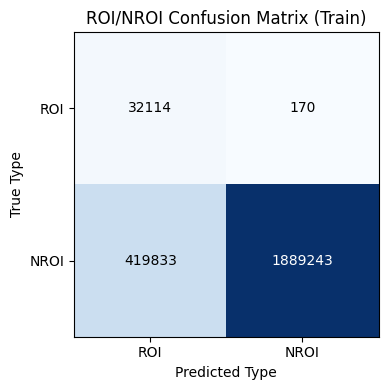


=== Train Binary Classification Report ===
              precision    recall  f1-score   support

         ROI       0.07      0.99      0.13     32284
        NROI       1.00      0.82      0.90   2309076

    accuracy                           0.82   2341360
   macro avg       0.54      0.91      0.52   2341360
weighted avg       0.99      0.82      0.89   2341360



In [13]:
b_label_to_type = {0: "NROI",1: "ROI"}
bdnn.eval()
with torch.no_grad():
    X_tr_tensor = torch.tensor(X_feat_tr, dtype=torch.float32).to(device)
    probs_tr      = torch.softmax(bdnn(X_tr_tensor), dim=1)[:, 1].cpu().numpy()
    y_type_pred_tr = (probs_tr > 0.5).astype(int)
    roi_mask_tr   = probs_tr > 0.5
    X_stage2_tr   = X_feat_tr[roi_mask_tr]
    y_stage2_tr   = y_tr[roi_mask_tr]

    X_te_tensor = torch.tensor(X_feat_te, dtype=torch.float32).to(device)
    probs_te      = torch.softmax(bdnn(X_te_tensor), dim=1)[:, 1].cpu().numpy()
    y_type_pred   = (probs_te > 0.5).astype(int)
    roi_mask_te   = probs_te > 0.5
    X_stage2_te   = X_feat_te[roi_mask_te]
    y_stage2_te   = y_te[roi_mask_te]


pred_types_strings = [b_label_to_type[int(p)] for p in y_type_pred_tr]
true_types_strings = [b_label_to_type[int(t)] for t in b_y_tr]
binary_labels = ["ROI", "NROI"]

cm_types_2 = np.array(confusion_matrix(
    true_types_strings,
    pred_types_strings,
    labels=binary_labels
))

plt.figure(figsize=(5, 4))
plt.imshow(cm_types_2, cmap="Blues")
plt.title("ROI/NROI Confusion Matrix (Train)")
plt.xticks(range(len(binary_labels)), binary_labels)
plt.yticks(range(len(binary_labels)), binary_labels)
plt.xlabel("Predicted Type")
plt.ylabel("True Type")
for i in range(len(binary_labels)):
    for j in range(len(binary_labels)):
        val = cm_types_2[i, j]
        plt.text(j, i, val, ha="center", va="center",
                color="white" if val > cm_types_2.max()/2 else "black")
plt.tight_layout()
plt.show()

print("\n=== Train Binary Classification Report ===")
print(classification_report(true_types_strings, pred_types_strings, labels=binary_labels))

In [4]:
valid_mask_tr = (y_stage2_tr != 3)
X_stage2_tr = X_stage2_tr[valid_mask_tr]
y_stage2_tr = y_stage2_tr[valid_mask_tr]

valid_mask_te = (y_stage2_te != 3)
X_stage2_te = X_stage2_te[valid_mask_te]
y_stage2_te = y_stage2_te[valid_mask_te]

remap = {0: 0, 1: 1, 2: 2, 4: 3}
y_stage2_tr = np.array([remap[y] for y in y_stage2_tr])
y_stage2_te = np.array([remap[y] for y in y_stage2_te])

label_to_type_2 = {0: "COL", 1: "CL", 2: "COH", 3: "BG"}

print(np.unique(y_stage2_tr, return_counts=True))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_stage2_tr),
    y=y_stage2_tr
)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)  

class CDNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),         nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),          nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 4),
        )
    def forward(self, x):
        return self.net(x)

cdnn = CDNN(X_stage2_tr.shape[1]).to(device)  

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(cdnn.parameters(), lr=1e-4)

def make_loader(X, y, batch_size, shuffle):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_stage2_tr, y_stage2_tr, BATCH, shuffle=True)
val_loader   = make_loader(X_stage2_te, y_stage2_te, BATCH, shuffle=False)

for epoch in range(1, EPOCHS + 1):
    cdnn.train()
    train_loss = train_correct = train_total = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # ← GPU

        optimizer.zero_grad()
        logits = cdnn(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * len(y_batch)
        train_correct += (logits.argmax(1) == y_batch).sum().item()
        train_total   += len(y_batch)

    cdnn.eval()
    val_loss = val_correct = val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)  

            logits      = cdnn(X_batch)
            loss        = criterion(logits, y_batch)
            val_loss    += loss.item() * len(y_batch)
            val_correct += (logits.argmax(1) == y_batch).sum().item()
            val_total   += len(y_batch)

    train_loss /= train_total;  train_acc = train_correct / train_total
    val_loss   /= val_total;    val_acc   = val_correct   / val_total

    print(f"Epoch {epoch}/{EPOCHS}  "
          f"loss: {train_loss:.4f}  acc: {train_acc:.4f}  "
          f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

torch.save(cdnn.state_dict(), "Stage2DNN.pt")
print('Saved DNN')

(array([0, 1, 2, 3]), array([  9034,  16236,   6804, 402600]))
Using device: cuda
Epoch 1/10  loss: 0.9937  acc: 0.2214  val_loss: 1.2135  val_acc: 0.1902
Epoch 2/10  loss: 0.7967  acc: 0.2124  val_loss: 1.1854  val_acc: 0.2030
Epoch 3/10  loss: 0.7624  acc: 0.1978  val_loss: 1.1777  val_acc: 0.1815
Epoch 4/10  loss: 0.7385  acc: 0.1930  val_loss: 1.1820  val_acc: 0.1824
Epoch 5/10  loss: 0.7208  acc: 0.1864  val_loss: 1.1581  val_acc: 0.1952
Epoch 6/10  loss: 0.7045  acc: 0.1871  val_loss: 1.1891  val_acc: 0.1724
Epoch 7/10  loss: 0.6968  acc: 0.1811  val_loss: 1.1829  val_acc: 0.1703
Epoch 8/10  loss: 0.6852  acc: 0.1793  val_loss: 1.1587  val_acc: 0.1808
Epoch 9/10  loss: 0.6745  acc: 0.1863  val_loss: 1.1686  val_acc: 0.1756
Epoch 10/10  loss: 0.6665  acc: 0.1880  val_loss: 1.1519  val_acc: 0.1912
Saved DNN


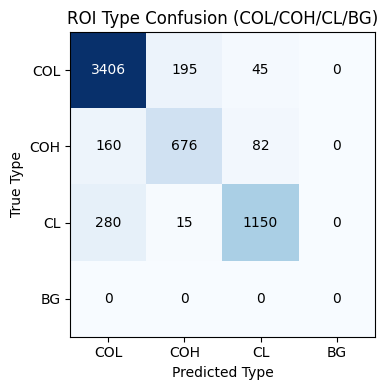

In [5]:
cdnn.eval()
with torch.no_grad():
    X_te_tensor = torch.tensor(X_stage2_te, dtype=torch.float32).to(device)
    y_type_pred_3 = cdnn(X_te_tensor).argmax(dim=1).cpu().numpy()

type_to_label_3 = {"COL": 0, "CL": 1, "COH": 2, "BG": 3}
label_to_type_3 = {v: k for k, v in type_to_label.items()}

pred_types_strings = [label_to_type_3[int(p)] for p in y_type_pred_3]
true_types_strings = [label_to_type_3[int(t)] for t in y_stage2_te]

#3x3 matrix (COL/COH/CL only)
labels3 = ["COL", "COH", "CL", "BG"]
mask_3class = np.array([t in labels3 for t in true_types_strings])
cm_types_3 = confusion_matrix(
    np.array(true_types_strings)[mask_3class],
    np.array(pred_types_strings)[mask_3class],
    labels=labels3
)

plt.figure(figsize=(5, 4))
plt.imshow(cm_types_3, cmap="Blues")
plt.title("ROI Type Confusion (COL/COH/CL/BG)")
plt.xticks(range(len(labels3)), labels3)
plt.yticks(range(len(labels3)), labels3)
plt.xlabel("Predicted Type")
plt.ylabel("True Type")
for i in range(len(labels3)):
    for j in range(len(labels3)):
        val = cm_types_3[i, j]
        plt.text(j, i, val, ha="center", va="center",
                color="white" if val > cm_types_3.max()/2 else "black")
plt.tight_layout()
plt.show()

In [6]:
# Per-type metrics
from sklearn.metrics import classification_report
print("\n=== ROI Type Classification Report ===")
print(classification_report(true_types_strings, pred_types_strings, labels=labels3))

# Calculate per-type recall
support = np.array([(np.array(true_types_strings) == t).sum() for t in labels3], dtype=float)
diag = np.diag(cm_types_3).astype(float)
recall_by_type = {t: (d / s if s > 0 else 0.0) for t, d, s in zip(labels3, diag, support)}
print("\nPer-type recall:", recall_by_type)

# F1 score
from sklearn.metrics import f1_score
print(f"Weighted F1 score: {f1_score(true_types_strings, pred_types_strings, average='weighted', labels=labels3):.3f}")


=== ROI Type Classification Report ===


c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.

              precision    recall  f1-score   support

         COL       0.04      0.79      0.08      4300
         COH       0.01      0.65      0.02      1046
          CL       0.02      0.72      0.04      1597
          BG       0.00      0.00      0.00         0

   micro avg       0.03      0.75      0.05      6943
   macro avg       0.02      0.54      0.04      6943
weighted avg       0.03      0.75      0.06      6943


Per-type recall: {'COL': np.float64(0.792093023255814), 'COH': np.float64(0.6462715105162524), 'CL': np.float64(0.720100187852223), 'BG': 0.0}
Weighted F1 score: 0.064


c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


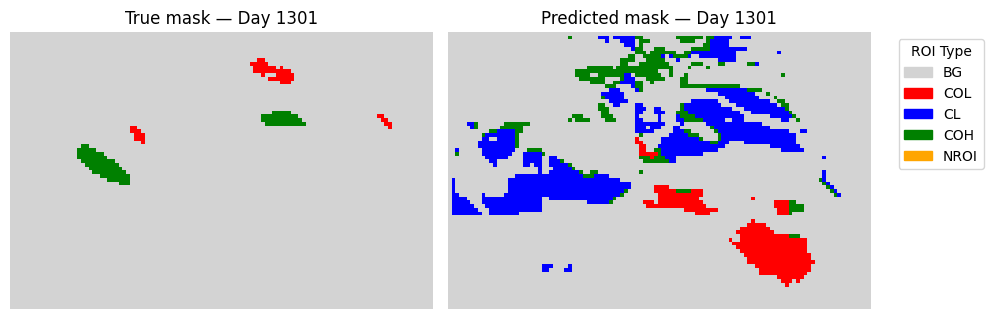

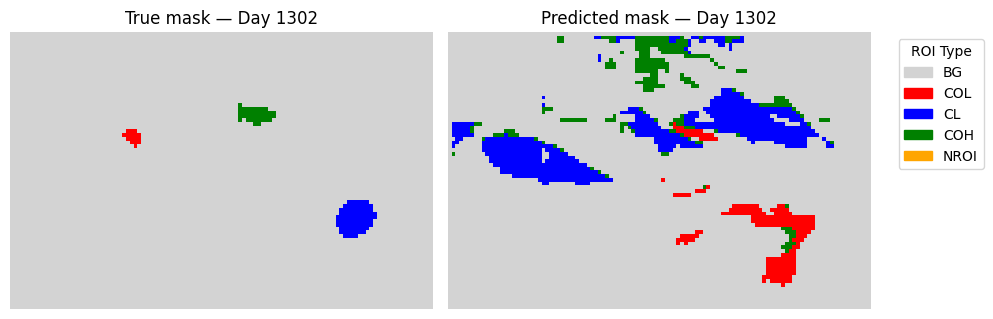

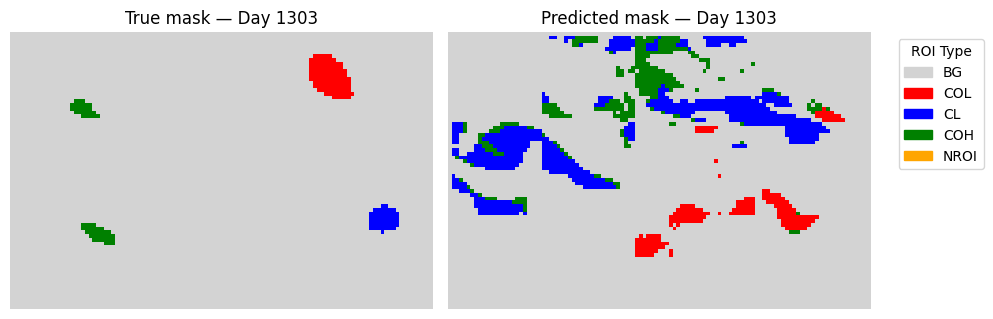

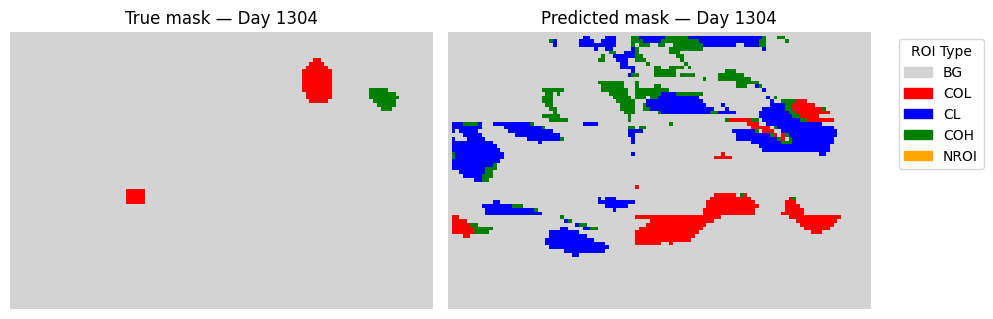

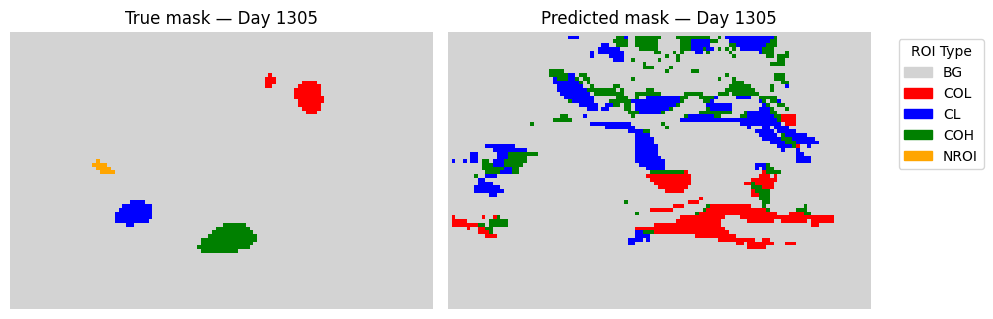

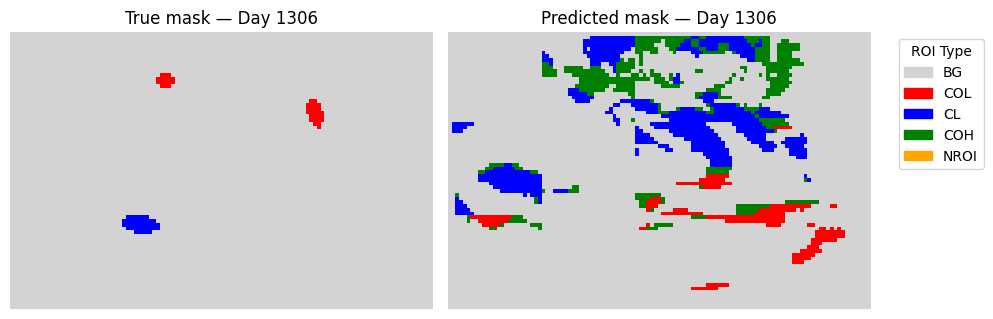

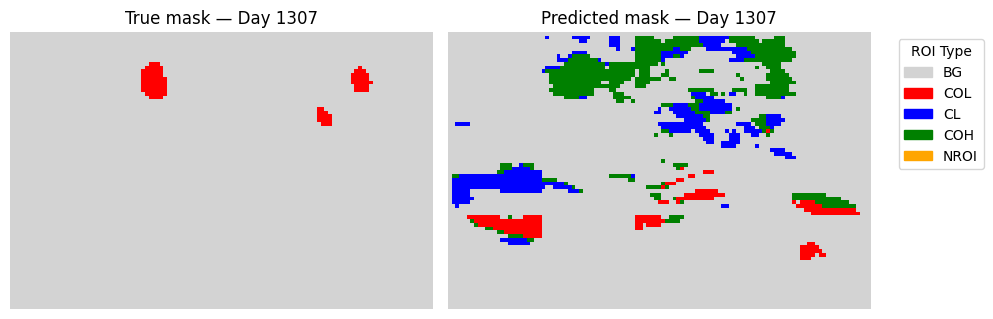

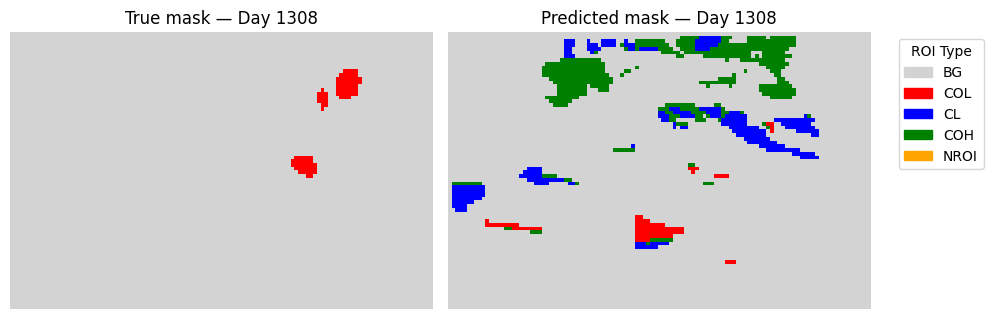

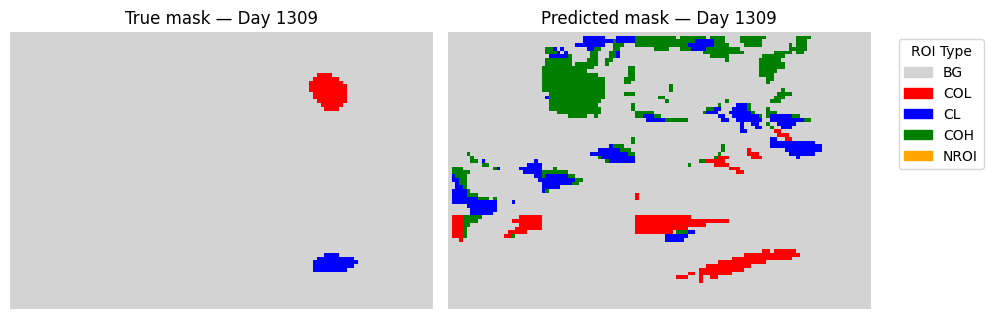

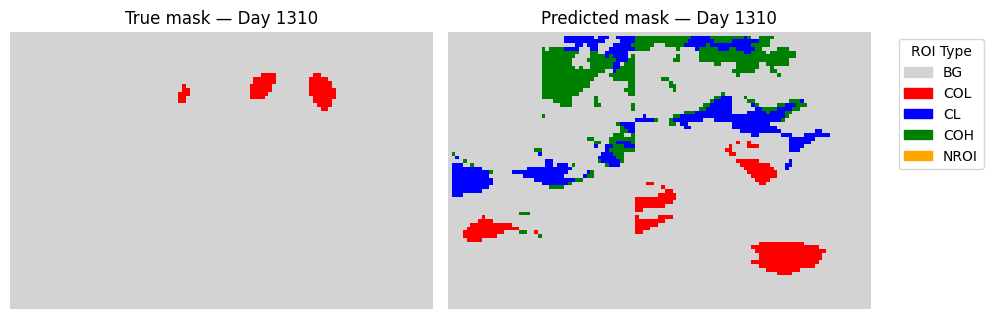

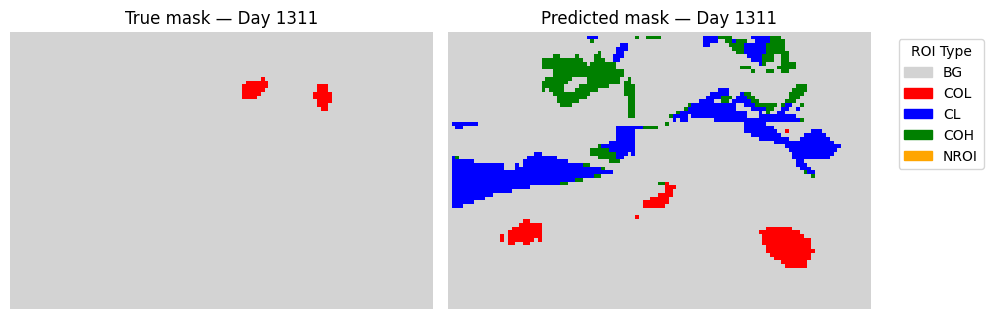

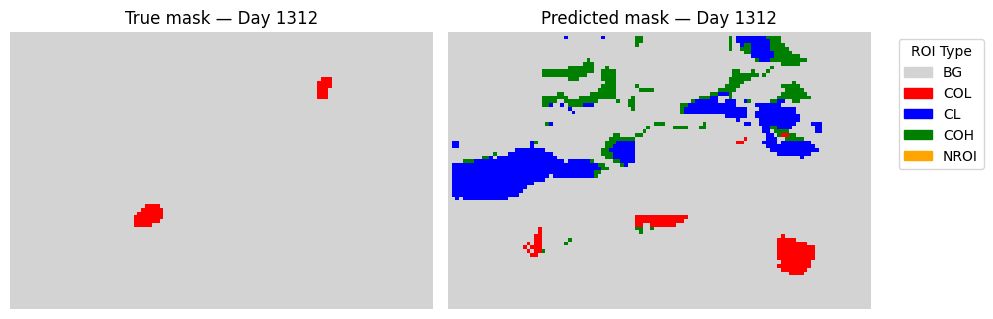

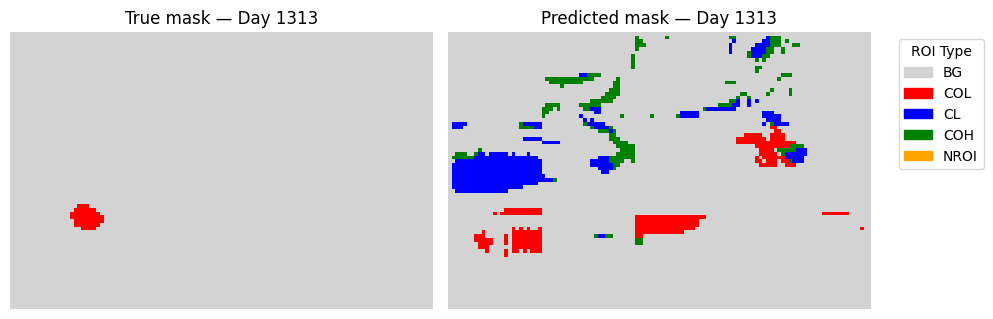

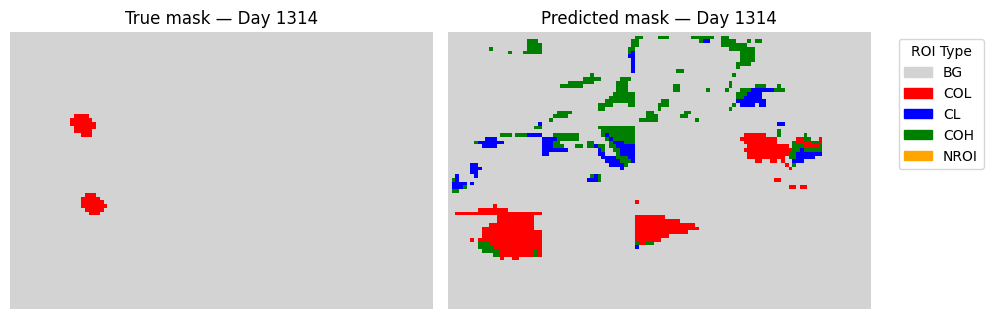

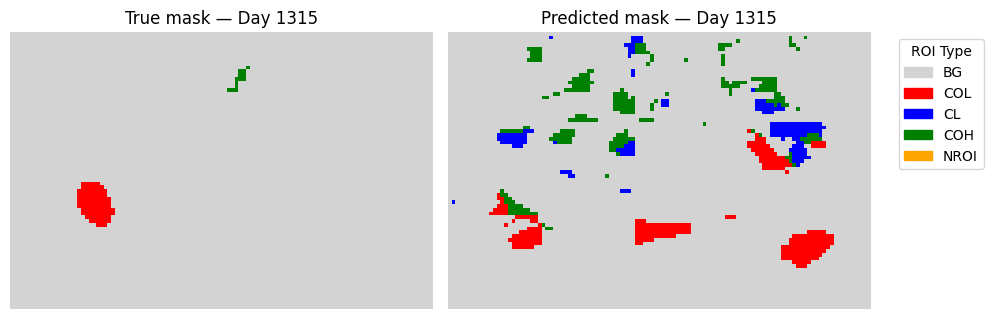

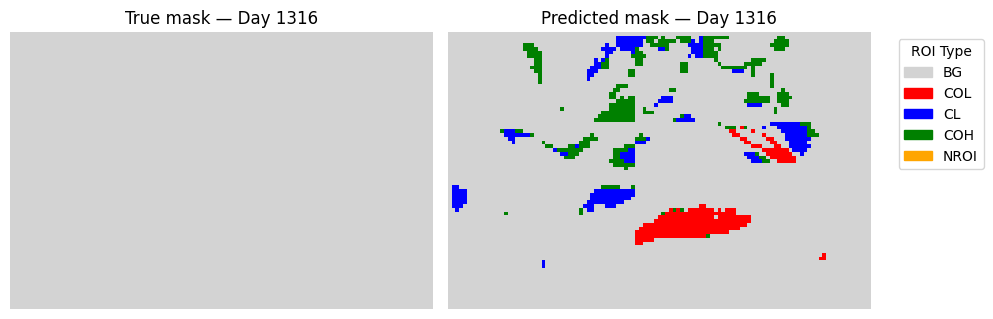

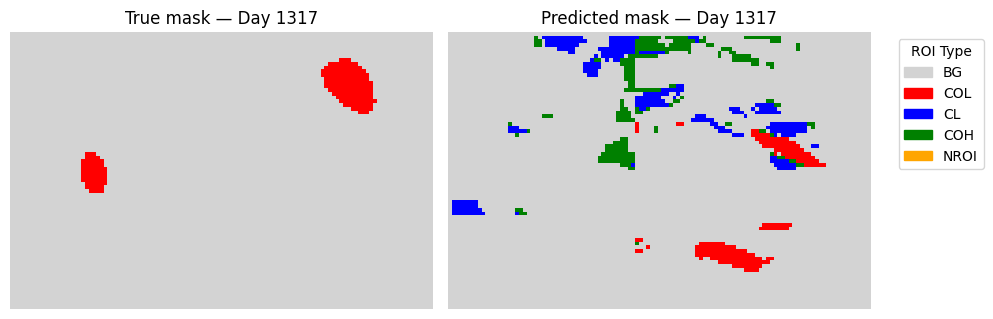

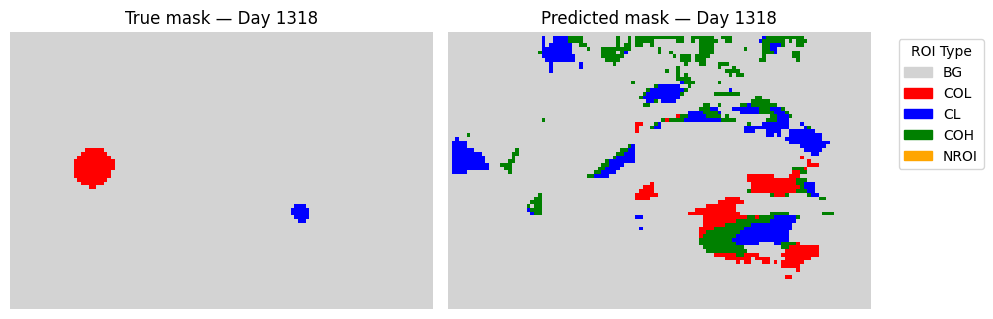

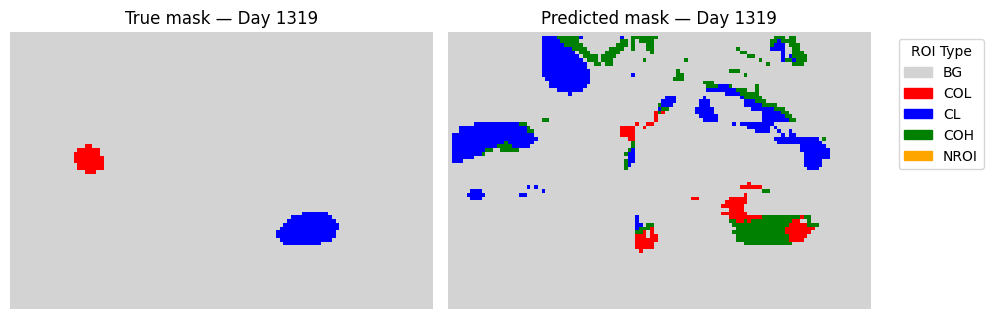

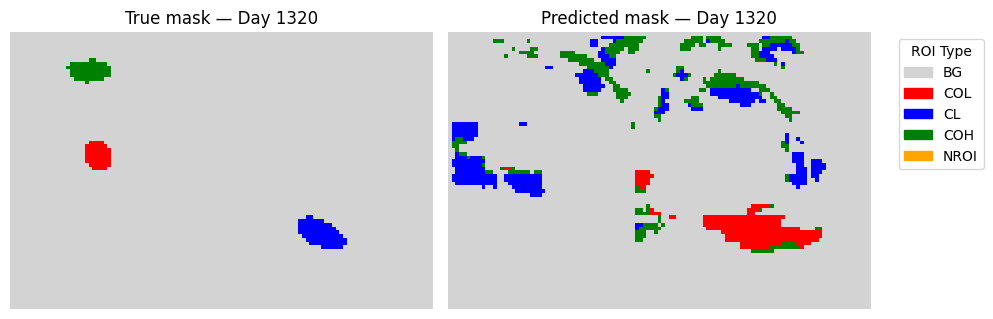

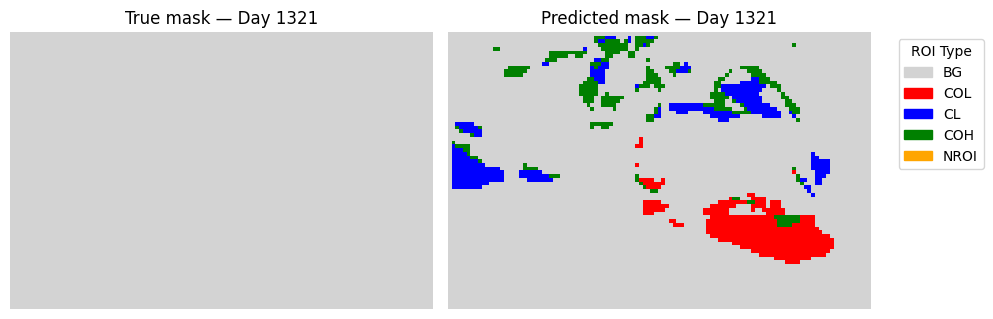

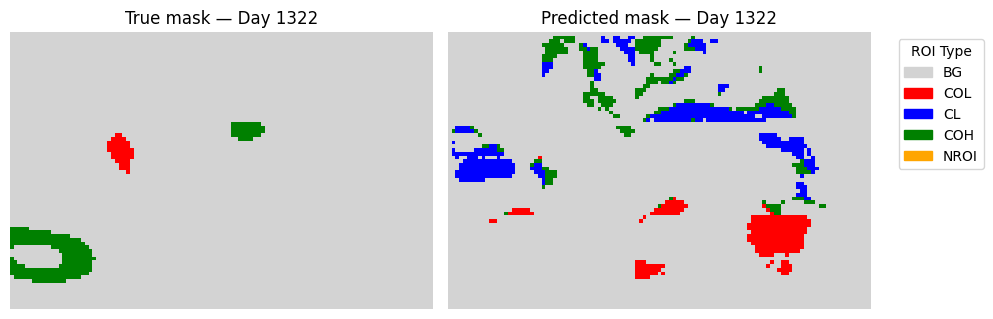

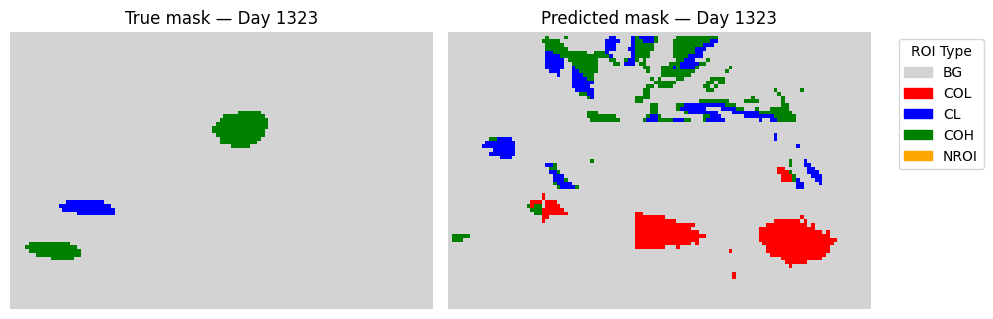

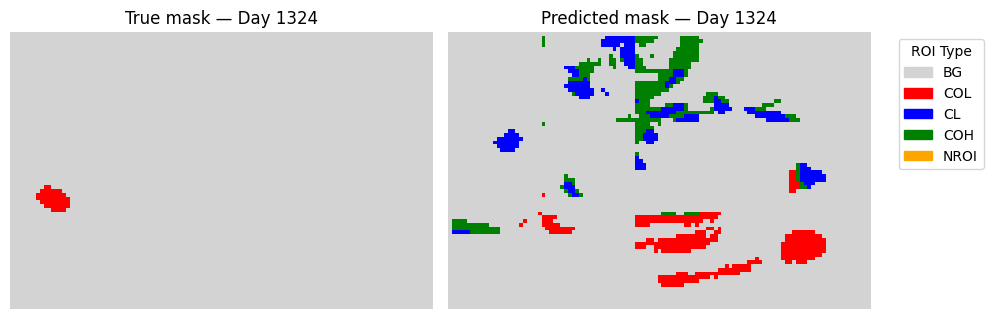

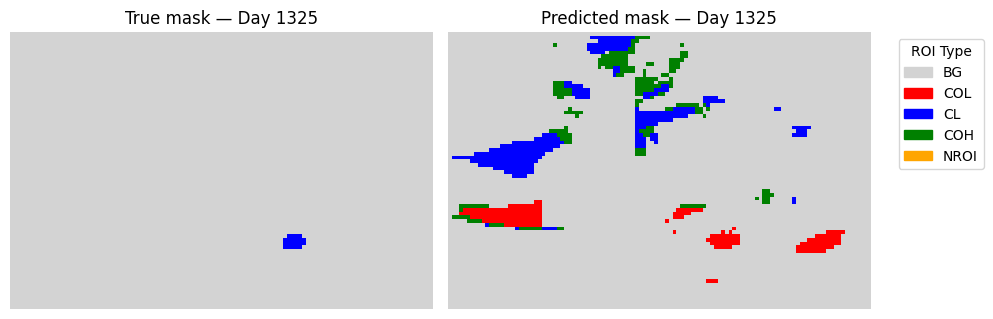

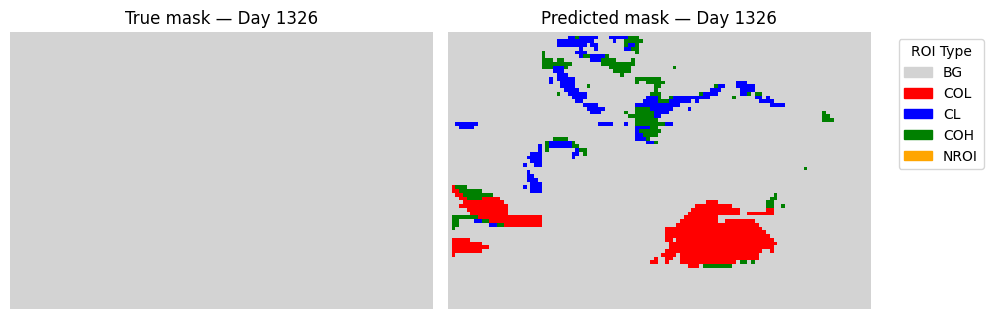

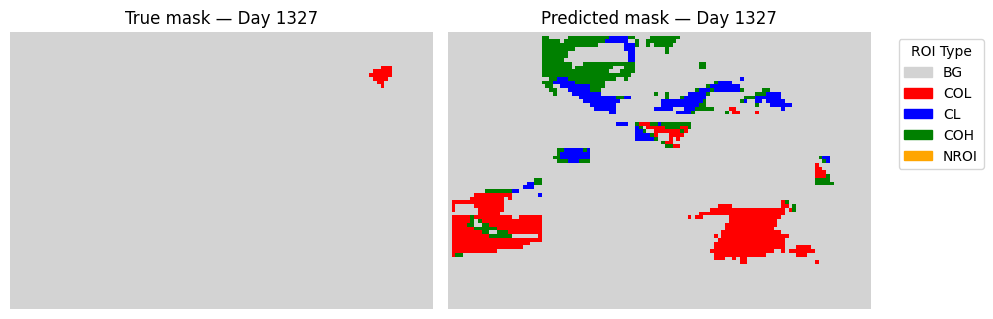

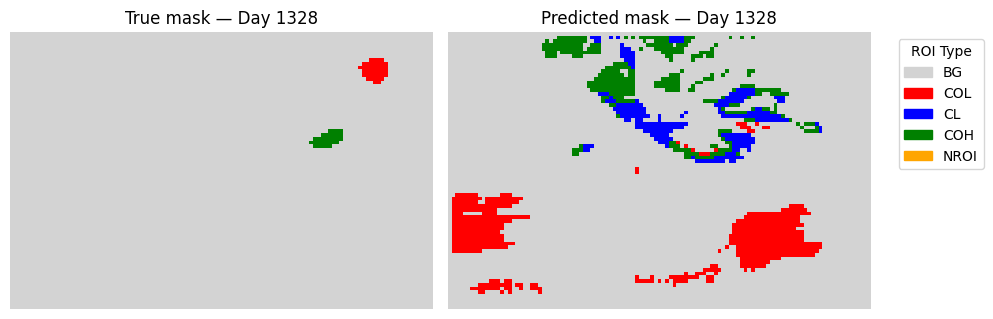

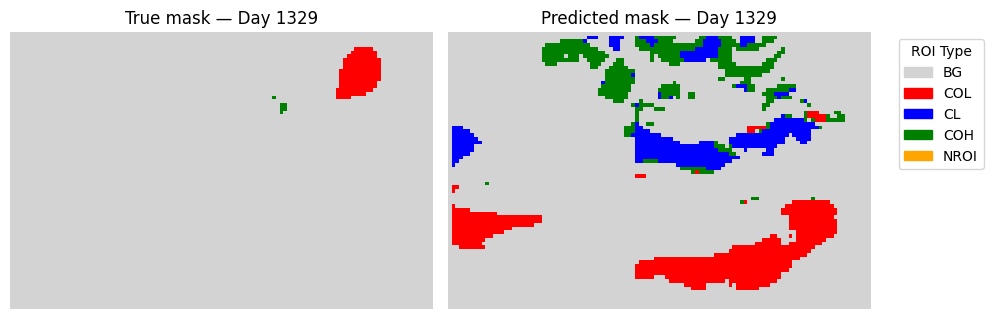

In [9]:
# === TRUE vs. PREDICTED ROI MASKS (color‐coded by type) ===
cmap_types = mcolors.ListedColormap(["lightgrey"] + ([TYPE_COLORS[t] for t in ROI_TYPES]))
type_code  = {t:i for i,t in enumerate(ROI_TYPES)}

stage2_idx = np.where(roi_mask_te)[0]     
final_idx = stage2_idx[(y_te[stage2_idx] != type_to_label["NROI"])]
y_final_pred = np.full(len(y_te), 0, dtype=int)
y_final_pred[final_idx] = y_type_pred_3

for day in TEST_DAYS:
    P,_        = load_grids(day-1)
    H,W        = P.shape
    true_mask  = create_roi_mask(roi_df,day,(H,W))
    sel        = (days_te==day)
    coords_day = coords_te[sel]
    types_day  = types_te[sel]
    preds_day  = y_final_pred[sel]

    pred_mask = np.zeros((H,W),dtype=int)
    for (x,y), pr in zip(coords_day, preds_day):
            pred_mask[H-1-y, x] = pr

    fig,(axT,axP) = plt.subplots(1,2,figsize=(10,5),sharex=True,sharey=True)
    axT.imshow(true_mask, cmap=cmap_types, origin="upper", vmin=0, vmax=len(ROI_TYPES))
    axT.set_title(f"True mask — Day {day}");  axT.axis("off")
    axP.imshow(pred_mask, cmap=cmap_types, origin="upper", vmin=0, vmax=len(ROI_TYPES))
    axP.set_title(f"Predicted mask — Day {day}"); axP.axis("off")

    patches = [mpatches.Patch(color=cmap_types(i), label=l)
            for i,l in enumerate(["BG"]+ROI_TYPES)]
    axP.legend(handles=patches, bbox_to_anchor=(1.05,1), loc="upper left", title="ROI Type")
    axT.invert_yaxis()
    axP.invert_yaxis()
    plt.tight_layout()
    plt.show()